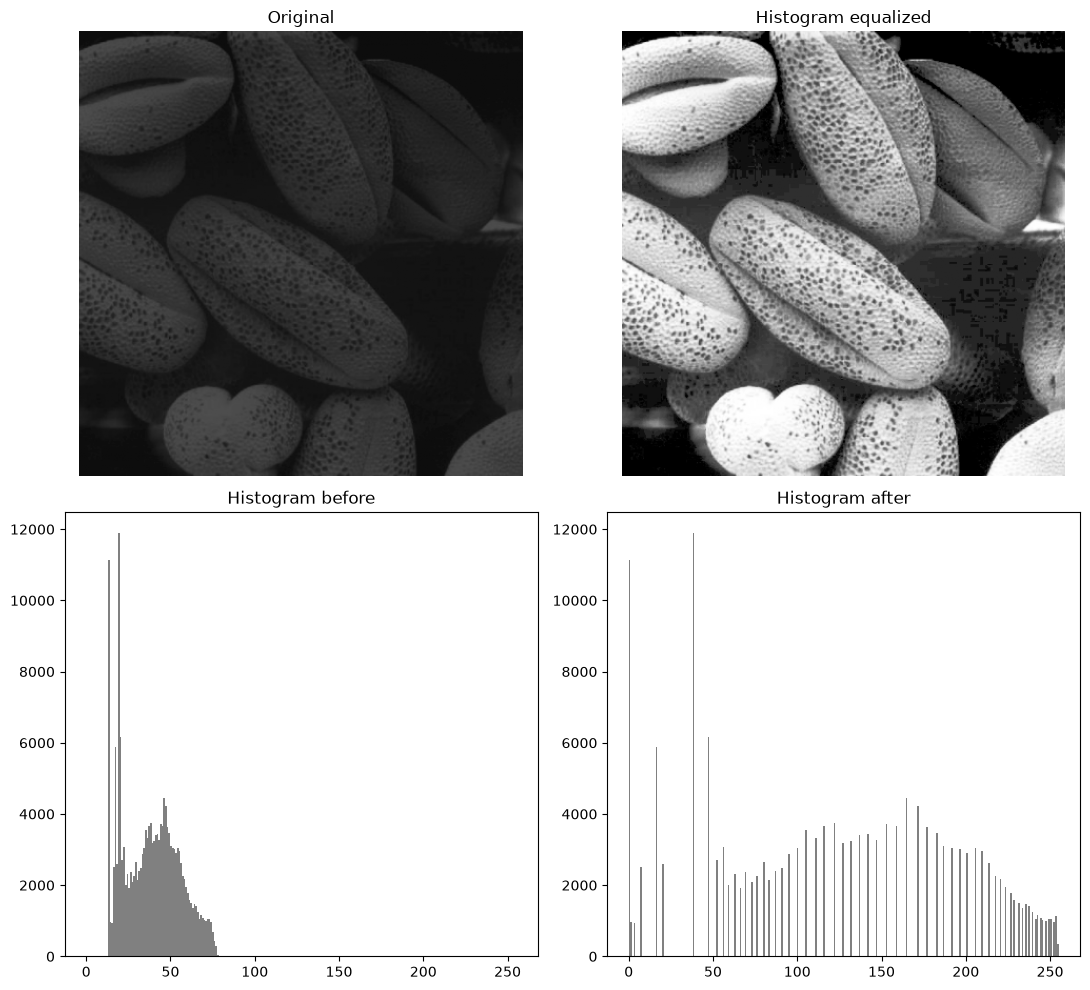

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im = cv.imread(r'D:\Image processing and Computer Vision\Images\rocks.png', cv.IMREAD_GRAYSCALE)
assert im is not None

equalized = cv.equalizeHist(im)

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes[0, 0].imshow(im, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original"); axes[0, 0].axis("off")

axes[0, 1].imshow(equalized, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Histogram equalized"); axes[0, 1].axis("off")

axes[1, 0].hist(im.ravel(), bins=256, range=(0, 255), color="gray")
axes[1, 0].set_title("Histogram before")

axes[1, 1].hist(equalized.ravel(), bins=256, range=(0, 255), color="gray")
axes[1, 1].set_title("Histogram after")

plt.tight_layout()
plt.show()

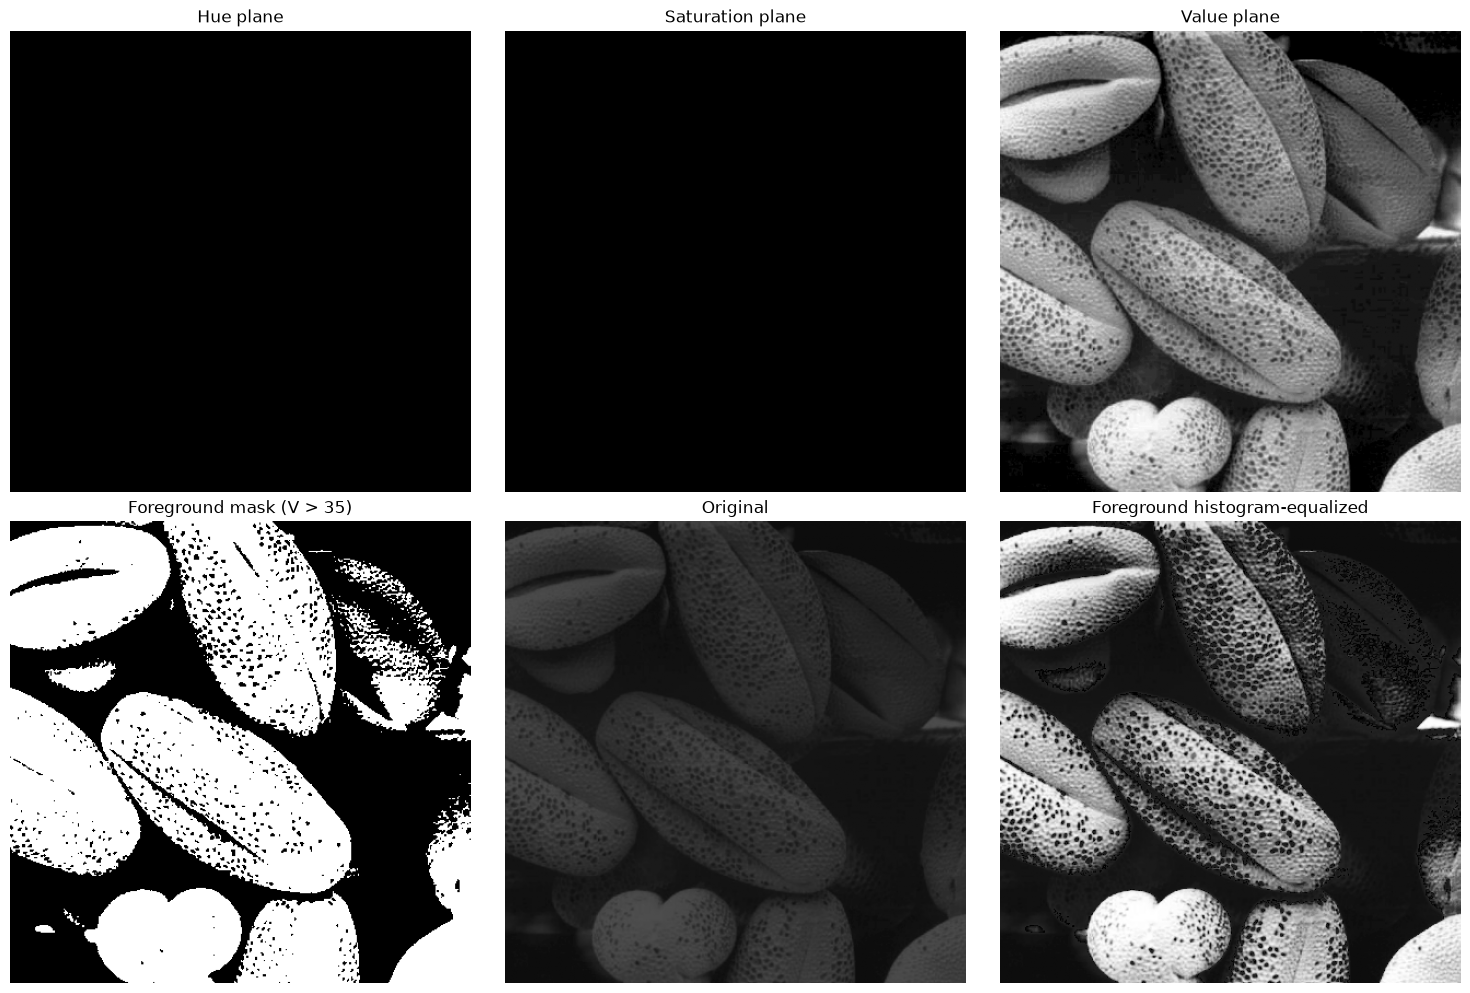

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im_bgr = cv.imread(r'D:\Image processing and Computer Vision\Images\rocks.png')          
assert im_bgr is not None

hsv = cv.cvtColor(im_bgr, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)

thresh = 35
_, mask = cv.threshold(v, thresh, 255, cv.THRESH_BINARY)   

gray = cv.cvtColor(im_bgr, cv.COLOR_BGR2GRAY)
foreground = cv.bitwise_and(gray, gray, mask=mask)

fg_pixels = gray[mask == 255].reshape(-1, 1)        
fg_pixels_eq = cv.equalizeHist(fg_pixels).flatten()

fg_equalized_full = np.zeros_like(gray)
fg_equalized_full[mask == 255] = fg_pixels_eq

inverse_mask = cv.bitwise_not(mask)
background = cv.bitwise_and(gray, gray, mask=inverse_mask)
result = cv.add(fg_equalized_full, background)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(h, cmap="gray"); axes[0, 0].set_title("Hue plane"); axes[0, 0].axis("off")
axes[0, 1].imshow(s, cmap="gray"); axes[0, 1].set_title("Saturation plane"); axes[0, 1].axis("off")
axes[0, 2].imshow(v, cmap="gray"); axes[0, 2].set_title("Value plane"); axes[0, 2].axis("off")
axes[1, 0].imshow(mask, cmap="gray"); axes[1, 0].set_title(f"Foreground mask (V > {thresh})"); axes[1, 0].axis("off")
axes[1, 1].imshow(gray, cmap="gray", vmin=0, vmax=255); axes[1, 1].set_title("Original"); axes[1, 1].axis("off")
axes[1, 2].imshow(result, cmap="gray", vmin=0, vmax=255); axes[1, 2].set_title("Foreground histogram-equalized"); axes[1, 2].axis("off")
plt.tight_layout()
plt.show()